# Step 0: Environment Initialization 

In [1]:
!pip install tensorflow
!pip install opencv-python
!pip install torchvision

In [2]:
# Basic imports and verify torch is cuda compatible (2.5.1+cu121)
import os
import torch
import numpy as np
import tensorflow as tf
import keras
import keras.backend as K
import cv2
from torchvision import datasets, transforms
from torch import nn
from tqdm.auto import tqdm
import nibabel as nib
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
from torch.utils.data import DataLoader

import pickle

#CUDA DEBUG TODO
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

torch.__version__

2025-04-11 17:59:27.688762: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744408767.706656   26915 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744408767.711853   26915 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1744408767.725120   26915 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1744408767.725138   26915 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1744408767.725139   26915 computation_placer.cc:177] computation placer alr

'2.6.0+cu124'

In [3]:
# Verify we are working on GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

# Step 1: Load & Process Data

In [4]:
# MUST BE MANUALLY REPOINTED FOR YOUR COMPUTER
TRAIN_DATASET_PATH = "C:/Users/zecer/proj/final/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/"
TRAIN_DATASET_PATH = os.path.join(os.getcwd(), "BraTS2020_TrainingData", "MICCAI_BraTS2020_TrainingData/")

old_name = os.path.join(TRAIN_DATASET_PATH, "BraTS20_Training_355/W39_1998.09.19_Segm.nii")
new_name = os.path.join(TRAIN_DATASET_PATH, "BraTS20_Training_355/BraTS20_Training_355_seg.nii")

# load .nii file as a numpy array
test_image_flair = nib.load(os.path.join(TRAIN_DATASET_PATH, "BraTS20_Training_355/BraTS20_Training_355_flair.nii")).get_fdata()
print("Shape: ", test_image_flair.shape)
print("Dtype: ", test_image_flair.dtype)

Shape:  (240, 240, 155)
Dtype:  float64


In [5]:
scaler = MinMaxScaler()

test_image_flair = scaler.fit_transform(test_image_flair.reshape(-1, test_image_flair.shape[-1])).reshape(test_image_flair.shape)

In [6]:
#images must be rescaled TODO: citation?

# rescaling t1
test_image_t1 = nib.load(os.path.join(TRAIN_DATASET_PATH, 'BraTS20_Training_355/BraTS20_Training_355_t1.nii')).get_fdata()
test_image_t1 = scaler.fit_transform(test_image_t1.reshape(-1, test_image_t1.shape[-1])).reshape(test_image_t1.shape)

# rescaling t1ce
test_image_t1ce = nib.load(os.path.join(TRAIN_DATASET_PATH, 'BraTS20_Training_355/BraTS20_Training_355_t1ce.nii')).get_fdata()
test_image_t1ce = scaler.fit_transform(test_image_t1ce.reshape(-1, test_image_t1ce.shape[-1])).reshape(test_image_t1ce.shape)

# rescaling t2
test_image_t2 = nib.load(os.path.join(TRAIN_DATASET_PATH, 'BraTS20_Training_355/BraTS20_Training_355_t2.nii')).get_fdata()
test_image_t2 = scaler.fit_transform(test_image_t2.reshape(-1, test_image_t2.shape[-1])).reshape(test_image_t2.shape)

# we will not rescale the mask
# no exist??
test_image_seg = nib.load(os.path.join(TRAIN_DATASET_PATH, 'BraTS20_Training_355/BraTS20_Training_355_seg.nii')).get_fdata()


Slice Number: 100


Text(0.5, 1.0, 'Mask')

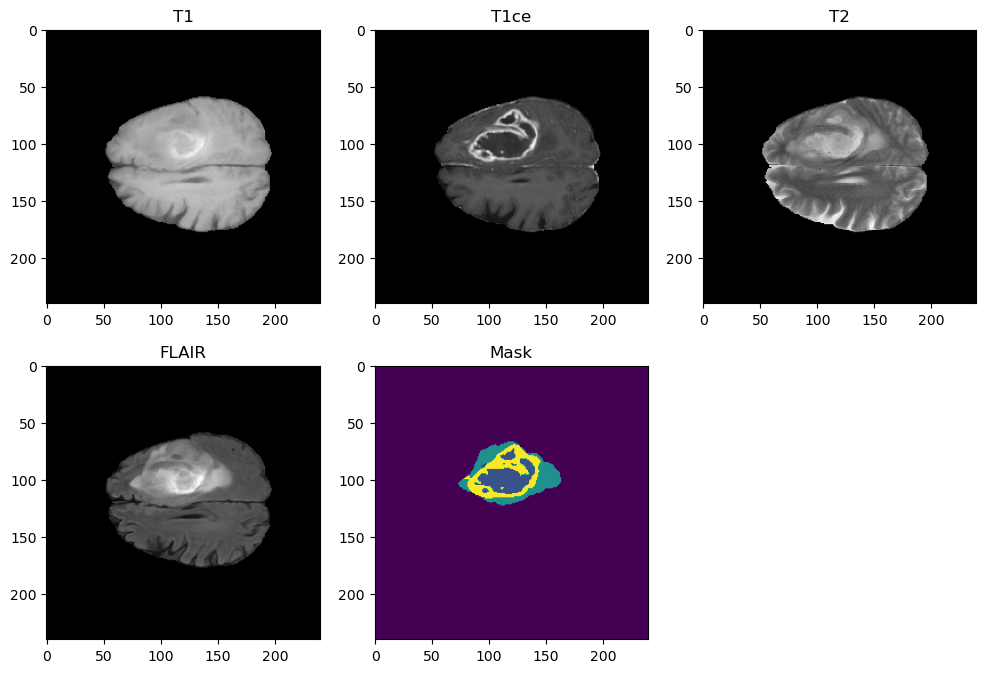

In [7]:
slice = 100

print("Slice Number: " + str(slice))

plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(test_image_t1[:,:,slice], cmap='gray')
plt.title('T1')

plt.subplot(2, 3, 2)
plt.imshow(test_image_t1ce[:,:,slice], cmap='gray')
plt.title('T1ce')

plt.subplot(2, 3, 3)
plt.imshow(test_image_t2[:,:,slice], cmap='gray')
plt.title('T2')

plt.subplot(2, 3, 4)
plt.imshow(test_image_flair[:,:,slice], cmap='gray')
plt.title('FLAIR')

plt.subplot(2, 3, 5)
plt.imshow(test_image_seg[:,:,slice])
plt.title('Mask')

In [8]:
train_and_val_directories = [f.path for f in os.scandir(TRAIN_DATASET_PATH) if f.is_dir()]

def pathListIntoIds(dirList):
    x = []
    for i in range(0,len(dirList)):
        x.append(dirList[i][dirList[i].rfind('/')+1:])
    return x

train_and_test_ids = pathListIntoIds(train_and_val_directories)

train_test_ids, val_ids = train_test_split(train_and_test_ids,test_size=0.2)
train_ids, test_ids = train_test_split(train_test_ids,test_size=0.15)

print('Distribution of data:')
print(f'Train length: {len(train_ids)}, ', end='')
print(f'Validation length: {len(val_ids)}, ', end='')
print(f'Test length: {len(test_ids)}, ', end='')

Distribution of data:
Train length: 250, Validation length: 74, Test length: 45, 

In [9]:
import os
import nibabel as nib
import numpy as np
import torch
from torch.utils.data import Dataset

class BRATSDataset2D(Dataset):
    def __init__(self, root_dir, modalities=["flair", "t1ce"], slice_axis=2, transform=None):
        self.root_dir = root_dir
        self.modalities = modalities
        self.slice_axis = slice_axis
        self.transform = transform

        # List all patient folders
        self.sample_paths = []
        for subdir in os.listdir(root_dir):
            full_path = os.path.join(root_dir, subdir)
            if os.path.isdir(full_path):
                flair_path = os.path.join(full_path, f"{subdir}_flair.nii")
                if os.path.exists(flair_path):
                    self.sample_paths.append(full_path)


        # Preload all slices as (patient_id, slice_index)
        self.slices = []
        for patient in self.sample_paths:
            mod_path = os.path.join(patient, f"{os.path.basename(patient)}_{modalities[0]}.nii")
            volume = nib.load(mod_path).get_fdata()
            num_slices = volume.shape[slice_axis]
            self.slices.extend([(patient, i) for i in range(num_slices)])

    def __len__(self):
        return len(self.slices)


    def __getitem__(self, idx):
        for attempt in range(10):
            try:
                patient_path, slice_idx = self.slices[idx]
                base = os.path.basename(patient_path)
                imgs = []

                for mod in self.modalities:
                    path = os.path.join(patient_path, f"{base}_{mod}.nii")
                    vol = nib.load(path).get_fdata()
                    vol = (vol - np.mean(vol)) / (np.std(vol) + 1e-8)
                    img = vol.take(indices=slice_idx, axis=self.slice_axis)
                    imgs.append(img)

                image = np.stack(imgs, axis=0)  # [C, H, W]
                seg_path = os.path.join(patient_path, f"{base}_seg.nii")
                seg = nib.load(seg_path).get_fdata()
                mask = seg.take(indices=slice_idx, axis=self.slice_axis)
                mask[mask == 4] = 3

                # Convert to tensors
                image = torch.tensor(image, dtype=torch.float32).unsqueeze(0)  # [1, C, H, W]
                mask = torch.tensor(mask, dtype=torch.long).unsqueeze(0).unsqueeze(0)  # [1, 1, H, W]

                # Resize both
                scale = 0.25
                new_h, new_w = int(image.shape[2] * scale), int(image.shape[3] * scale)
                image = F.interpolate(image, size=(new_h, new_w), mode='bilinear', align_corners=False)
                #mask = F.interpolate(mask.float(), size=(new_h, new_w), mode='nearest').long()
                # Resize mask to match model output size (56x56)
                mask = F.interpolate(mask.float(), size=(56, 56), mode='nearest').long()


                return image.squeeze(0), mask.squeeze(0).squeeze(0)

            except Exception as e:
                print(f"Skipping invalid sample at index {idx}: {e}")
                idx = (idx + 1) % len(self.slices)

        raise RuntimeError("Too many failed attempts to load a valid slice")


In [10]:
from torch.utils.data import random_split

train_full = BRATSDataset2D(root_dir=TRAIN_DATASET_PATH, modalities=["flair", "t1ce", "t1", "t2"])
train_size = int(0.8 * len(train_full))
val_size = len(train_full) - train_size
train_dataset, val_dataset = random_split(train_full, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

# Step 2: Initialize Model Architecture

In [30]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        # Ensure prediction is sigmoid or softmaxed
        if pred.shape[1] == 1:  # binary
            pred = torch.sigmoid(pred)
        else:
            pred = F.softmax(pred, dim=1)

        # If target is not one-hot, convert it
        if target.ndim == 3 or target.shape[1] == 1:
            target = F.one_hot(target.long(), num_classes=pred.shape[1])
            target = target.permute(0, 3, 1, 2).float()

        intersection = (pred * target).sum(dim=(2, 3))
        union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
        dice_score = (2 * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice_score.mean()


class HybridLoss(nn.Module):
    def __init__(self, alpha=0.5, beta=0.5):
        super(HybridLoss, self).__init__()
        self.dice_loss = DiceLoss()
        self.ce_loss = nn.CrossEntropyLoss() 
        self.alpha = alpha
        self.beta = beta

    def forward(self, seg_pred, seg_target):
        dice = self.dice_loss(seg_pred, seg_target)
        ce_seg = self.ce_loss(seg_pred, seg_target.long())
        
        total_loss = dice * ce_seg
        return total_loss


In [12]:
# dice loss as defined above for 4 classes
def dice_coef(y_true, y_pred, smooth=1.0):
    class_num = 4
    for i in range(class_num):
        y_true_f = K.flatten(y_true[:,:,:,i])
        y_pred_f = K.flatten(y_pred[:,:,:,i])
        intersection = K.sum(y_true_f * y_pred_f)
        loss = ((2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth))
        if i == 0:
            total_loss = loss
        else:
            total_loss = total_loss + loss
    total_loss = total_loss / class_num
    return total_loss

# Define per class evaluation of dice coef
def dice_coef_necrotic(y_true, y_pred, epsilon=1e-6):
    intersection = K.sum(K.abs(y_true[:,:,:,1] * y_pred[:,:,:,1]))
    return (2. * intersection) / (K.sum(K.square(y_true[:,:,:,1])) + K.sum(K.square(y_pred[:,:,:,1])) + epsilon)

def dice_coef_edema(y_true, y_pred, epsilon=1e-6):
    intersection = K.sum(K.abs(y_true[:,:,:,2] * y_pred[:,:,:,2]))
    return (2. * intersection) / (K.sum(K.square(y_true[:,:,:,2])) + K.sum(K.square(y_pred[:,:,:,2])) + epsilon)

def dice_coef_enhancing(y_true, y_pred, epsilon=1e-6):
    intersection = K.sum(K.abs(y_true[:,:,:,3] * y_pred[:,:,:,3]))
    return (2. * intersection) / (K.sum(K.square(y_true[:,:,:,3])) + K.sum(K.square(y_pred[:,:,:,3])) + epsilon)

In [13]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_initializer=None):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        if kernel_initializer:
            for m in self.conv:
                if isinstance(m, nn.Conv2d):
                    kernel_initializer(m.weight)

    def forward(self, x):
        return self.conv(x)

def center_crop(enc_feat, target_feat):
    """Center-crop enc_feat to match the spatial size of target_feat."""
    _, _, h, w = target_feat.shape
    enc_h, enc_w = enc_feat.shape[2], enc_feat.shape[3]
    crop_y = (enc_h - h) // 2
    crop_x = (enc_w - w) // 2
    return enc_feat[:, :, crop_y:crop_y + h, crop_x:crop_x + w]

class BuildModel(nn.Module):
    def __init__(self, in_channels=4, out_channels=4, dropout=0.5, kernel_initializer=None):
        super(BuildModel, self).__init__()

        # Encoder
        self.down1 = DoubleConv(in_channels, 32, kernel_initializer)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(32, 64, kernel_initializer)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(64, 128, kernel_initializer)
        self.pool3 = nn.MaxPool2d(2)

        # Bottleneck
        self.middle = DoubleConv(128, 256, kernel_initializer)
        self.dropout = nn.Dropout(dropout)

        # Decoder
        self.up1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.upconv1 = DoubleConv(256, 128, kernel_initializer)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.upconv2 = DoubleConv(128, 64, kernel_initializer)

        self.up3 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.upconv3 = DoubleConv(64, 32, kernel_initializer)

        # Output
        self.final = nn.Conv2d(32, out_channels, kernel_size=1)

    def forward(self, x):
        c1 = self.down1(x)
        p1 = self.pool1(c1)

        c2 = self.down2(p1)
        p2 = self.pool2(c2)

        c3 = self.down3(p2)
        p3 = self.pool3(c3)

        m = self.middle(p3)
        m = self.dropout(m)

        u1 = self.up1(m)
        c3_cropped = center_crop(c3, u1)
        u1 = self.upconv1(torch.cat([c3_cropped, u1], dim=1))

        u2 = self.up2(u1)
        c2_cropped = center_crop(c2, u2)
        u2 = self.upconv2(torch.cat([c2_cropped, u2], dim=1))

        u3 = self.up3(u2)
        c1_cropped = center_crop(c1, u3)
        u3 = self.upconv3(torch.cat([c1_cropped, u3], dim=1))

        return self.final(u3)


# Step 3: Define Train and Test Step Behavior

In [14]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):
  model.train() # Convert model to train mode

  train_loss, train_acc = 0, 0
  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)
    # Do the forward pass
    y_pred = model(X)
    # Calculate th loss
    loss = loss_fn(y_pred, y)
    train_loss += loss.item()
    # Optimizer zero grad
    optimizer.zero_grad()
    # Loss backward
    loss.backward()
    # Optimizer step
    optimizer.step()

    # Calc accuracy
    y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
    train_acc += (y_pred_class==y).sum().item()/len(y_pred)

  train_loss = train_loss / len(dataloader)
  train_acc = train_acc /  len(dataloader)
  return train_loss, train_acc

In [15]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):
  model.eval() # Convert model to inference mode

  test_loss, test_acc = 0, 0

  with torch.inference_mode():
    for batch, (X, y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device)
      # Forward pass
      test_pred_logits = model(X)
      # Calculate the loss
      loss = loss_fn(test_pred_logits, y)
      test_loss += loss.item()
      # Calc acc
      test_pred_labels = test_pred_logits.argmax(dim=1)
      test_acc += ((test_pred_labels==y)).sum().item()/len(test_pred_labels)

    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

In [16]:
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs: int):

    # Create empty results dictionary
    results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    # loop through training and testing steps EPOCH times
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer)
        test_loss, test_acc = test_step(model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn)

        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.3f} | "
            f"train_acc: {train_acc:.3f} | "
            f"test_loss: {test_loss:.3f} | "
            f"test_acc: {test_acc:.3f}"
        )

        # Update results dictionary
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    return results

# Step 4: Training the Model

In [17]:
# TODO: SPECIFY ALL PARAMS EG IN_CHANNELS=2? \
# NOTE: CAN EASILY SCALE IN CHANNELS TO 4

In [18]:
model = BuildModel(in_channels=2, out_channels=4)
for name, param in model.named_parameters():
    if torch.isnan(param).any():
        print(f"NaNs in {name}")


In [19]:
# Init an instance of custom model
model = BuildModel(in_channels=4, out_channels=4, kernel_initializer=None).to(device)
# model = GoodNet(in_channels=4, out_channels=1).to(device)

# Set up loss function and optimizer
# loss_fn = nn.CrossEntropyLoss()
loss_fn = HybridLoss(alpha=0.5, beta=0.5)
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1)

In [20]:
from timeit import default_timer as timer
start_time = timer()

# Train loop
NUM_EPOCHS = 5
# model_results = train(model=model,
#                         train_dataloader=train_loader,
#                         test_dataloader=val_loader,
#                         optimizer=optimizer,
#                         loss_fn=loss_fn,
#                         epochs=NUM_EPOCHS)

end_time = timer()
print(f"Training time was {end_time-start_time} seconds.")

Training time was 2.9795999580528587e-05 seconds.


# apply trained model
load model if exists

sad if not

In [21]:
modalities = ["flair", "t1ce"]

if os.path.exists("./unet_brats_weights.pth"):
    state_dict = torch.load("./unet_brats_weights.pth")
model = BuildModel(in_channels=len(modalities), out_channels=4, kernel_initializer=None).to(device)
model.load_state_dict(state_dict)
model.eval()

BuildModel(
  (down1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(2, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down3): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
 

### transforms images to relevant format

In [22]:
def transform_img(img_base, modalities, slice_idx, slice_axis=2):
    imgs = []

    for mod in modalities:
        path = os.path.join(img_base, f"{img_base}_{mod}.nii")
        vol = nib.load(path).get_fdata()
        vol = (vol - np.mean(vol)) / (np.std(vol) + 1e-8)
        img = vol.take(indices=slice_idx, axis=slice_axis)
        imgs.append(img)

    image = np.stack(imgs, axis=0)  # [C, H, W]

    # Convert to tensors
    image = torch.tensor(image, dtype=torch.float32).unsqueeze(0)  # [1, C, H, W]

    # Resize
    scale = 0.25
    new_h, new_w = int(image.shape[2] * scale), int(image.shape[3] * scale)
    image = F.interpolate(image, size=(new_h, new_w), mode='bilinear', align_corners=False)

    return image.squeeze(0)


### show one predicted segmentation

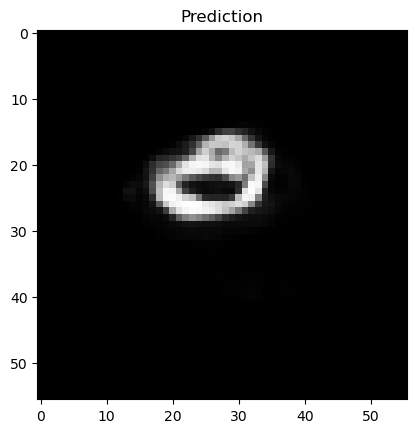

In [ ]:
slice_idx = 100
img_base = os.path.join(TRAIN_DATASET_PATH, "BraTS20_Training_355", "BraTS20_Training_355")
image = transform_img(img_base, modalities, slice_idx)
image = image.to(device).unsqueeze(0)

with torch.no_grad():
    prediction = model(image)
    prediction = torch.softmax(prediction, dim=1)
    pred = prediction.squeeze(0).cpu().numpy()
    plt.Figure(figsize=(12, 8))
    plt.imshow(pred[0], cmap='gray')
    plt.title('Prediction');

### overlayed on brain

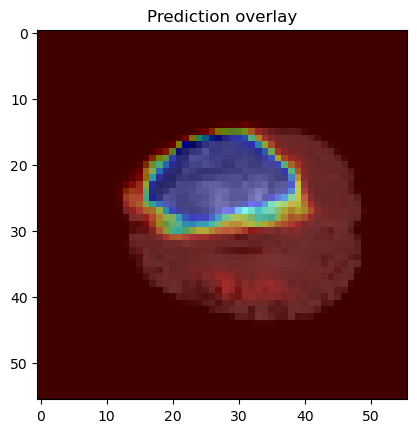

In [24]:
img = image.squeeze(0).cpu().numpy()
plt.Figure(figsize=(12, 8))
plt.imshow(img[0], cmap='gray')
plt.imshow(pred[0], cmap='jet', alpha=0.5)
plt.title('Prediction overlay');

### showing many brains/predicted segmentations

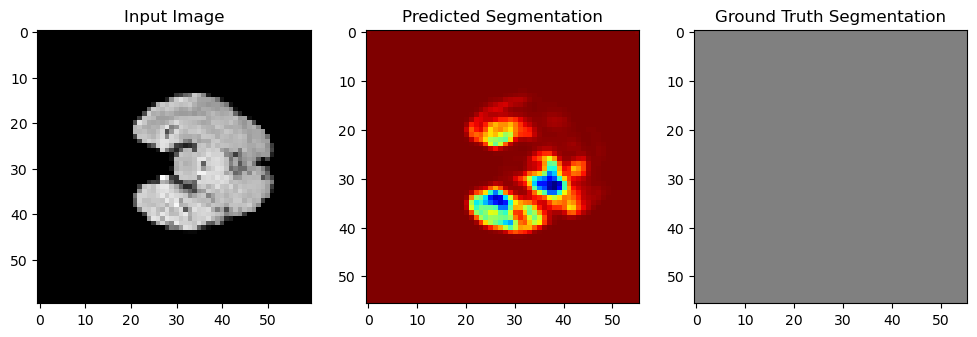

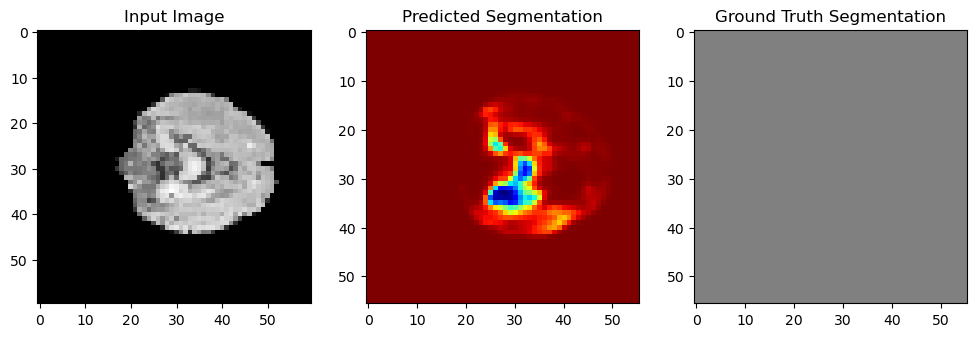

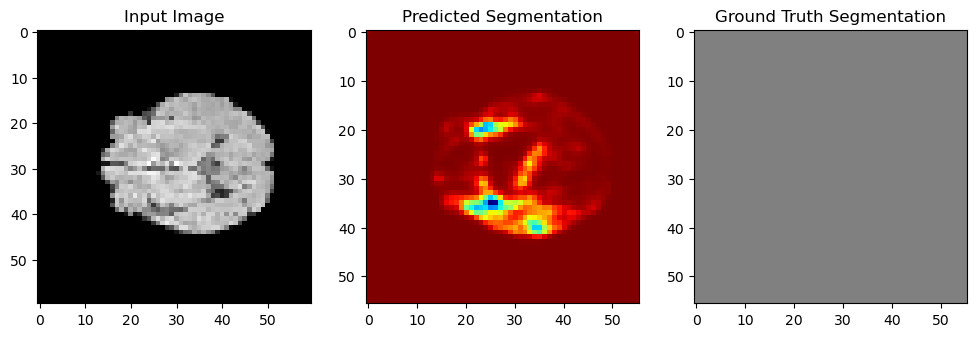

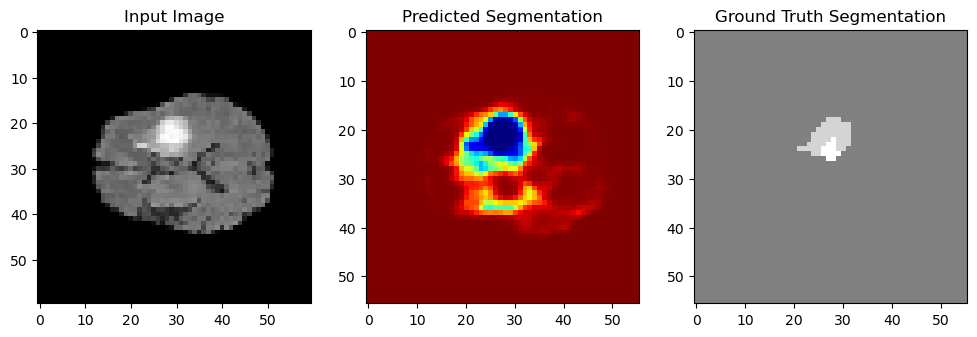

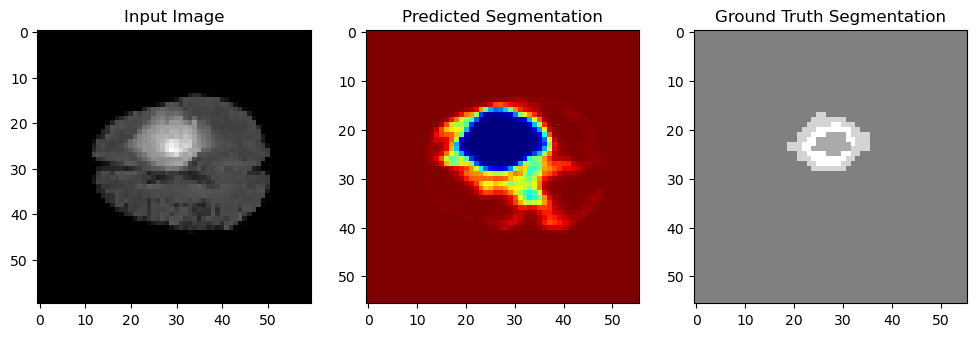

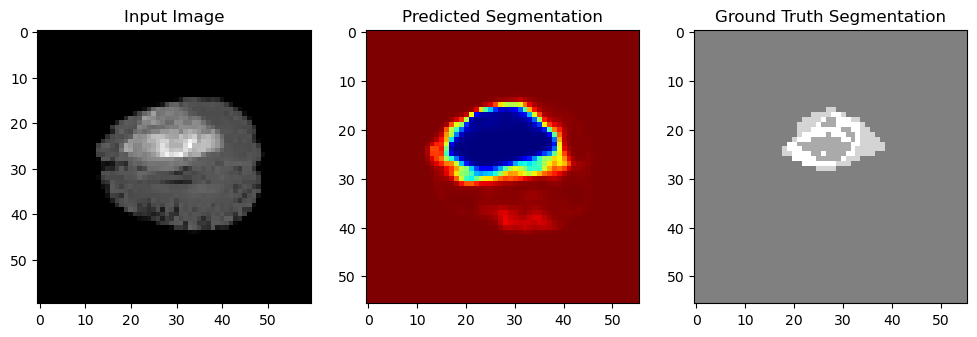

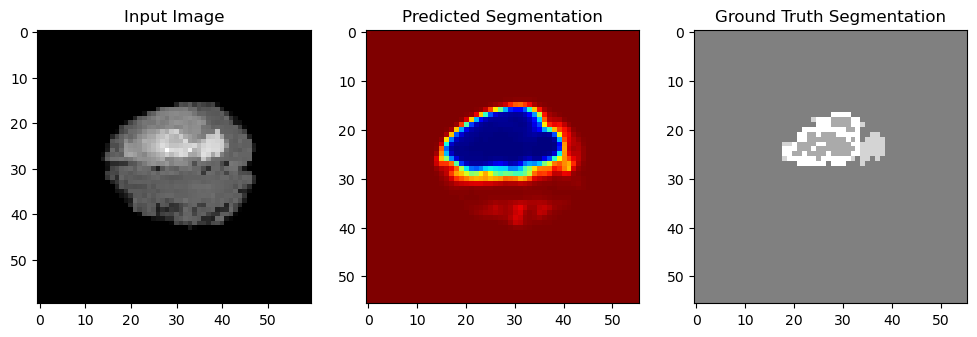

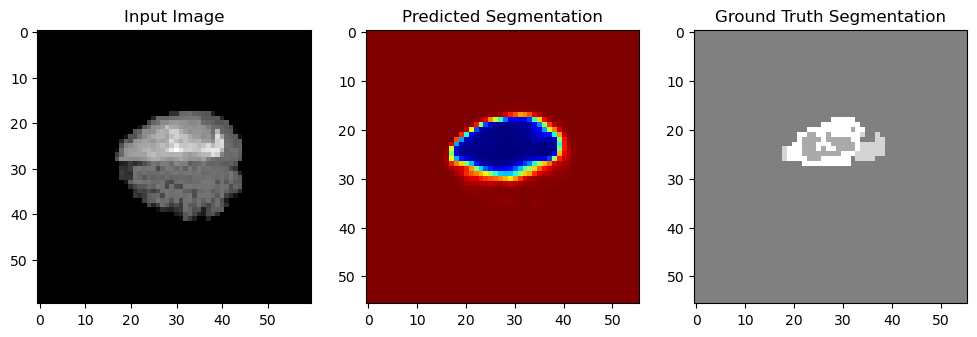

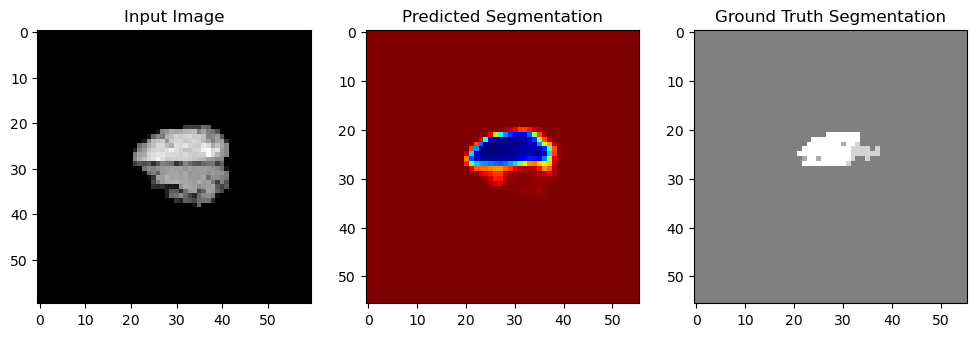

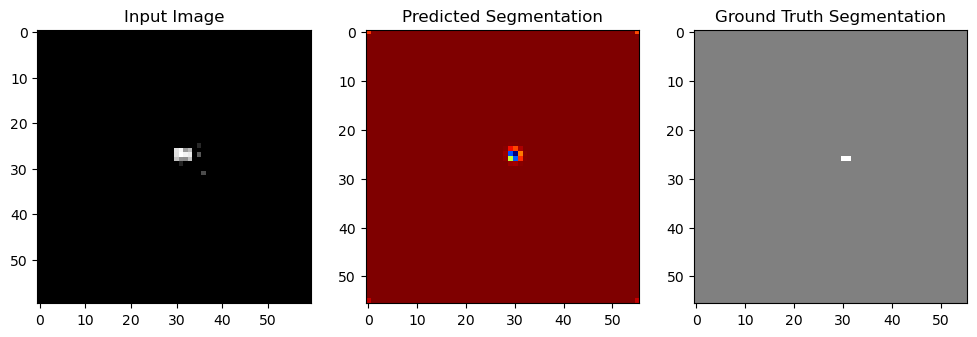

In [28]:

for idx in range(50, 150, 10):
    img_base = os.path.join(TRAIN_DATASET_PATH, "BraTS20_Training_355", "BraTS20_Training_355")
    image = transform_img(img_base, modalities, idx)
    image = image.to(device).unsqueeze(0)

    seg = nib.load(os.path.join(TRAIN_DATASET_PATH, "BraTS20_Training_355", "BraTS20_Training_355_seg.nii")).get_fdata()
    seg = seg.take(indices=idx, axis=2)
    seg[seg == 4] = 3
    seg = torch.tensor(seg, dtype=torch.long).unsqueeze(0).unsqueeze(0)  # [1, 1, H, W]
    seg = F.interpolate(seg.float(), size=(56, 56), mode='nearest').long()
    seg = seg.squeeze(0).squeeze(0).cpu().numpy()


    with torch.no_grad():
        pred = model(image)
        pred = torch.softmax(pred, dim=1)
        pred = pred.squeeze(0).cpu().numpy()

        plt.figure(figsize=(12, 8))
        plt.subplot(1, 3, 1)
        plt.imshow(image[0][0].cpu().numpy(), cmap='gray')
        plt.title('Input Image')

        plt.subplot(1, 3, 2)
        plt.imshow(pred[0], cmap='jet')
        plt.title('Predicted Segmentation')

        plt.subplot(1, 3, 3)
        plt.imshow(seg, cmap='gray', alpha=0.5)
        plt.title('Ground Truth Segmentation')

        plt.show()


